# Stage 5: Feed-Forward Networks in Transformers

## Where Most Parameters Live!

In a transformer, the **Feed-Forward Network (FFN)** contains ~2/3 of all parameters!

```
GPT-2 Small (124M params):
├── Embeddings:     ~38M  (31%)
├── Attention:      ~28M  (23%)
└── FFN:            ~57M  (46%)  ← Almost half!
```

### What FFN Does

After attention mixes information **between tokens**, FFN processes each token **independently**:

```
Attention: "Which other tokens should I pay attention to?"
FFN:       "Now that I have that context, what does it mean?"
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

---
## 1. The Classic FFN (Original Transformer)

### Structure

```
Input (d_model) → Linear → ReLU → Linear → Output (d_model)
      512       →  2048  →      →  512
```

### The Expansion Factor

FFN **expands** then **compresses**:
- Input: d_model (e.g., 512)
- Hidden: d_ff = 4 × d_model (e.g., 2048)
- Output: d_model (e.g., 512)

**Why expand?** The hidden layer acts as a "thinking space" with more capacity.

In [ ]:
class FFN(nn.Module):
    """
    Original Transformer FFN
    
    FFN(x) = ReLU(xW₁ + b₁)W₂ + b₂
    """
    
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model  # Default: 4x expansion
        
        self.linear1 = nn.Linear(d_model, d_ff)   # Expand
        self.linear2 = nn.Linear(d_ff, d_model)   # Compress
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = self.linear1(x)        # (batch, seq_len, d_ff)
        x = F.relu(x)              # Activation
        x = self.dropout(x)
        x = self.linear2(x)        # (batch, seq_len, d_model)
        return x

In [ ]:
# Test and count parameters
d_model = 512
d_ff = 2048

ffn = FFN(d_model, d_ff)
x = torch.randn(2, 10, d_model)
out = ffn(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")

# Parameter count
params = sum(p.numel() for p in ffn.parameters())
print(f"\nParameter breakdown:")
print(f"  W1: {d_model} × {d_ff} = {d_model * d_ff:,}")
print(f"  b1: {d_ff:,}")
print(f"  W2: {d_ff} × {d_model} = {d_ff * d_model:,}")
print(f"  b2: {d_model:,}")
print(f"  Total: {params:,}")

Input shape:  torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])

Parameter breakdown:
  W1: 512 × 2048 = 1,048,576
  b1: 2,048
  W2: 2048 × 512 = 1,048,576
  b2: 512
  Total: 2,099,712


---
## 2. Activation Functions

The choice of activation function has evolved:

| Era | Model | Activation |
|-----|-------|------------|
| 2017 | Original Transformer | ReLU |
| 2018 | BERT, GPT | GELU |
| 2020 | GPT-3 | GELU |
| 2023 | LLaMA, Mistral | SwiGLU |

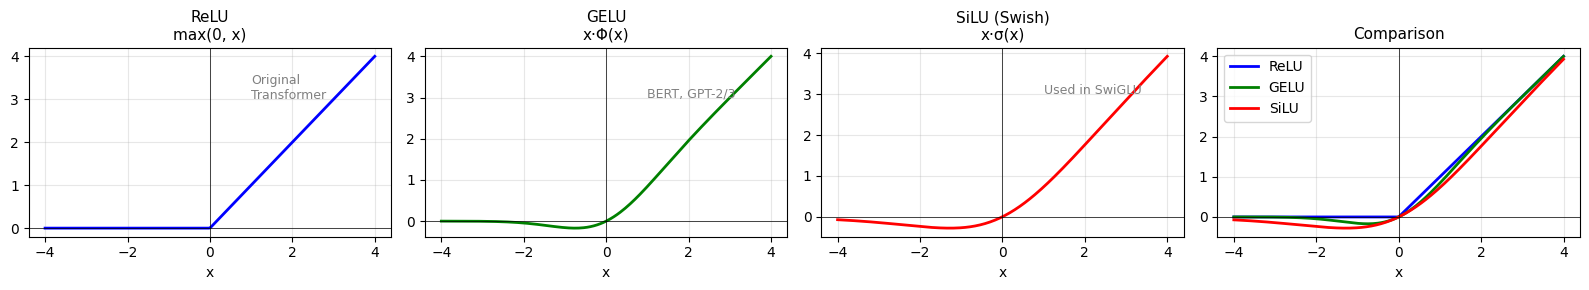

Key differences:
  ReLU:  Hard cutoff at 0, can cause 'dead neurons'
  GELU:  Smooth, allows small negative values
  SiLU:  Smooth, self-gated (x controls its own activation)


In [ ]:
# Visualize activation functions
x = torch.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))

# ReLU
ax = axes[0]
y = F.relu(x)
ax.plot(x.numpy(), y.numpy(), 'b-', linewidth=2)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax.set_title('ReLU\nmax(0, x)', fontsize=11)
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)
ax.text(1, 3, 'Original\nTransformer', fontsize=9, color='gray')

# GELU
ax = axes[1]
y = F.gelu(x)
ax.plot(x.numpy(), y.numpy(), 'g-', linewidth=2)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax.set_title('GELU\nx·Φ(x)', fontsize=11)
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)
ax.text(1, 3, 'BERT, GPT-2/3', fontsize=9, color='gray')

# SiLU (Swish)
ax = axes[2]
y = F.silu(x)  # SiLU = x * sigmoid(x) = Swish
ax.plot(x.numpy(), y.numpy(), 'r-', linewidth=2)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax.set_title('SiLU (Swish)\nx·σ(x)', fontsize=11)
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)
ax.text(1, 3, 'Used in SwiGLU', fontsize=9, color='gray')

# Comparison
ax = axes[3]
ax.plot(x.numpy(), F.relu(x).numpy(), 'b-', linewidth=2, label='ReLU')
ax.plot(x.numpy(), F.gelu(x).numpy(), 'g-', linewidth=2, label='GELU')
ax.plot(x.numpy(), F.silu(x).numpy(), 'r-', linewidth=2, label='SiLU')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax.set_title('Comparison', fontsize=11)
ax.set_xlabel('x')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key differences:")
print("  ReLU:  Hard cutoff at 0, can cause 'dead neurons'")
print("  GELU:  Smooth, allows small negative values")
print("  SiLU:  Smooth, self-gated (x controls its own activation)")

---
## 3. GELU Activation

**Gaussian Error Linear Unit** - used in BERT and GPT.

### Formula

$$\text{GELU}(x) = x \cdot \Phi(x)$$

Where Φ(x) is the cumulative distribution function of standard normal.

### Approximation (for faster computation)

$$\text{GELU}(x) \approx 0.5x \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}(x + 0.044715x^3)\right]\right)$$

### Intuition

GELU is like a **soft gate**: it lets through values based on how "extreme" they are.
- Large positive x → passes through mostly unchanged
- Large negative x → gets squashed toward 0
- Values near 0 → partial pass (smooth transition)

In [ ]:
class FFN_GELU(nn.Module):
    """
    FFN with GELU activation (BERT/GPT style)
    """
    
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        x = self.linear1(x)
        x = F.gelu(x)  # Smooth activation
        x = self.dropout(x)
        x = self.linear2(x)
        return x

---
## 4. Gated Linear Units (GLU)

**Key insight**: Instead of applying activation directly, use part of the network to **gate** the other part.

### GLU Formula

$$\text{GLU}(x) = (xW_1) \odot \sigma(xW_2)$$

Where:
- $\odot$ is element-wise multiplication
- $\sigma$ is sigmoid
- One linear produces values, another produces gates!

### Intuition

```
Traditional:  value → activation(value) → output
GLU:          value → value × gate → output
                        ↑
                  learned separately!
```

The network learns **what to let through** as a separate function.

In [ ]:
class GLU(nn.Module):
    """
    Gated Linear Unit
    
    GLU(x) = (xW₁ + b₁) ⊙ σ(xW₂ + b₂)
    
    Split into two halves: one for values, one for gates.
    """
    
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        # Project to 2x size, then split
        self.linear = nn.Linear(d_model, d_ff * 2)
        
    def forward(self, x):
        x = self.linear(x)  # (batch, seq, 2*d_ff)
        
        # Split into value and gate
        value, gate = x.chunk(2, dim=-1)  # Each: (batch, seq, d_ff)
        
        # Gate controls what passes through
        return value * torch.sigmoid(gate)

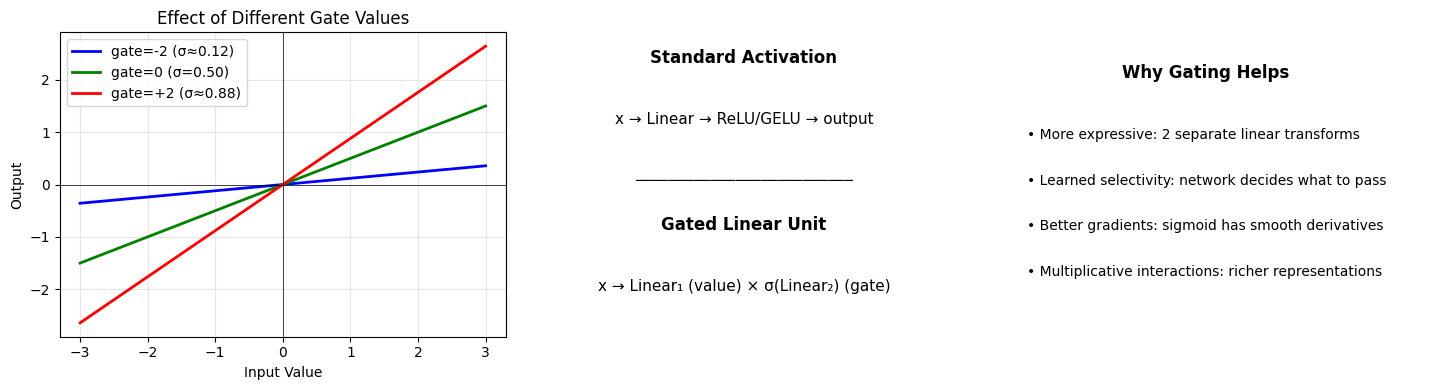

In [ ]:
# Visualize gating
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Create example
values = torch.linspace(-3, 3, 100)
gates_low = torch.sigmoid(torch.tensor(-2.0))   # ~0.12
gates_mid = torch.sigmoid(torch.tensor(0.0))    # 0.5
gates_high = torch.sigmoid(torch.tensor(2.0))   # ~0.88

ax = axes[0]
ax.plot(values.numpy(), (values * gates_low).numpy(), 'b-', linewidth=2, label='gate=-2 (σ≈0.12)')
ax.plot(values.numpy(), (values * gates_mid).numpy(), 'g-', linewidth=2, label='gate=0 (σ=0.50)')
ax.plot(values.numpy(), (values * gates_high).numpy(), 'r-', linewidth=2, label='gate=+2 (σ≈0.88)')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax.set_title('Effect of Different Gate Values')
ax.set_xlabel('Input Value')
ax.set_ylabel('Output')
ax.legend()
ax.grid(True, alpha=0.3)

# Show gating concept
ax = axes[1]
ax.text(0.5, 0.9, 'Standard Activation', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.7, 'x → Linear → ReLU/GELU → output', ha='center', fontsize=11, transform=ax.transAxes)
ax.text(0.5, 0.5, '──────────────────────────', ha='center', transform=ax.transAxes)
ax.text(0.5, 0.35, 'Gated Linear Unit', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.15, 'x → Linear₁ (value) × σ(Linear₂) (gate)', ha='center', fontsize=11, transform=ax.transAxes)
ax.axis('off')

# Show why gating helps
ax = axes[2]
ax.text(0.5, 0.85, 'Why Gating Helps', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.1, 0.65, '• More expressive: 2 separate linear transforms', ha='left', fontsize=10, transform=ax.transAxes)
ax.text(0.1, 0.5, '• Learned selectivity: network decides what to pass', ha='left', fontsize=10, transform=ax.transAxes)
ax.text(0.1, 0.35, '• Better gradients: sigmoid has smooth derivatives', ha='left', fontsize=10, transform=ax.transAxes)
ax.text(0.1, 0.2, '• Multiplicative interactions: richer representations', ha='left', fontsize=10, transform=ax.transAxes)
ax.axis('off')

plt.tight_layout()
plt.show()

---
## 5. SwiGLU (State of the Art)

**SwiGLU** = **Swi**sh + **GLU**. Used in **LLaMA**, **Mistral**, **PaLM**, and most modern LLMs.

### Formula

$$\text{SwiGLU}(x) = (xW_1) \odot \text{SiLU}(xW_2)$$

Where SiLU (Swish) = x × σ(x)

### Why SwiGLU?

1. **SiLU is smoother** than sigmoid as a gate
2. **Better performance** in practice
3. **Self-gated**: SiLU(x) = x × σ(x) naturally incorporates gating

### The Catch: More Parameters!

GLU/SwiGLU needs **3 linear layers** instead of 2:
- W_gate (for gating)
- W_up (for values)  
- W_down (final projection)

To keep parameter count similar, we reduce d_ff:
- Classic FFN: d_ff = 4 × d_model
- SwiGLU: d_ff = (2/3) × 4 × d_model ≈ 2.67 × d_model

In [ ]:
class SwiGLU(nn.Module):
    """
    SwiGLU Feed-Forward Network (LLaMA style)
    
    SwiGLU(x) = (xW_up) ⊙ SiLU(xW_gate) then project down
    
    Used in: LLaMA, Mistral, PaLM, Gemma
    """
    
    def __init__(self, d_model, d_ff=None, dropout=0.0):
        super().__init__()
        # Reduced d_ff to compensate for extra layer
        # LLaMA uses: d_ff = (4 * d_model * 2/3) rounded to multiple of 256
        d_ff = d_ff or int(4 * d_model * 2 / 3)
        
        # Three linear layers!
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)  # For gating
        self.w_up = nn.Linear(d_model, d_ff, bias=False)    # For values
        self.w_down = nn.Linear(d_ff, d_model, bias=False)  # Project back
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # Gated activation
        gate = F.silu(self.w_gate(x))  # SiLU activation on gate
        up = self.w_up(x)               # Value pathway
        
        # Element-wise gating
        x = gate * up
        x = self.dropout(x)
        
        # Project back to d_model
        x = self.w_down(x)
        return x

In [ ]:
# Compare parameter counts
d_model = 512

# Classic FFN (d_ff = 4 * d_model)
ffn_classic = FFN(d_model, d_ff=4*d_model, dropout=0.0)
params_classic = sum(p.numel() for p in ffn_classic.parameters())

# SwiGLU (d_ff = 4 * d_model * 2/3)
swiglu = SwiGLU(d_model)
params_swiglu = sum(p.numel() for p in swiglu.parameters())

print("Classic FFN (d_ff = 4 × d_model):")
print(f"  W1: {d_model} × {4*d_model} = {d_model * 4*d_model:,}")
print(f"  b1: {4*d_model:,}")
print(f"  W2: {4*d_model} × {d_model} = {4*d_model * d_model:,}")
print(f"  b2: {d_model:,}")
print(f"  Total: {params_classic:,}")

d_ff_swiglu = int(4 * d_model * 2 / 3)
print(f"\nSwiGLU (d_ff = {d_ff_swiglu}):")
print(f"  W_gate: {d_model} × {d_ff_swiglu} = {d_model * d_ff_swiglu:,}")
print(f"  W_up:   {d_model} × {d_ff_swiglu} = {d_model * d_ff_swiglu:,}")
print(f"  W_down: {d_ff_swiglu} × {d_model} = {d_ff_swiglu * d_model:,}")
print(f"  Total: {params_swiglu:,}")

print(f"\nRatio: SwiGLU uses {params_swiglu/params_classic:.1%} of Classic FFN params")

Classic FFN (d_ff = 4 × d_model):
  W1: 512 × 2048 = 1,048,576
  b1: 2,048
  W2: 2048 × 512 = 1,048,576
  b2: 512
  Total: 2,099,712

SwiGLU (d_ff = 1365):
  W_gate: 512 × 1365 = 698,880
  W_up:   512 × 1365 = 698,880
  W_down: 1365 × 512 = 698,880
  Total: 2,096,640

Ratio: SwiGLU uses 99.9% of Classic FFN params


In [ ]:
# Alternative: Fused SwiGLU (single matmul for gate and up)

class SwiGLUFused(nn.Module):
    """
    Fused SwiGLU - more efficient implementation
    
    Combines w_gate and w_up into a single matrix multiplication.
    """
    
    def __init__(self, d_model, d_ff=None, dropout=0.0):
        super().__init__()
        d_ff = d_ff or int(4 * d_model * 2 / 3)
        
        # Fused gate and up projection
        self.w_gate_up = nn.Linear(d_model, d_ff * 2, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # Single matmul, then split
        gate_up = self.w_gate_up(x)  # (batch, seq, 2*d_ff)
        gate, up = gate_up.chunk(2, dim=-1)
        
        # Gated activation
        x = F.silu(gate) * up
        x = self.dropout(x)
        x = self.w_down(x)
        return x


# Same parameter count, potentially faster
swiglu_fused = SwiGLUFused(d_model)
params_fused = sum(p.numel() for p in swiglu_fused.parameters())
print(f"SwiGLU Fused params: {params_fused:,}")
print(f"Same as unfused: {params_fused == params_swiglu}")

SwiGLU Fused params: 2,096,640
Same as unfused: True


---
## 6. GeGLU (Alternative)

**GeGLU** = **GE**LU + **GLU**. Sometimes used as an alternative to SwiGLU.

$$\text{GeGLU}(x) = (xW_1) \odot \text{GELU}(xW_2)$$

In [ ]:
class GeGLU(nn.Module):
    """
    GeGLU: GELU-gated Linear Unit
    
    Similar to SwiGLU but uses GELU instead of SiLU.
    """
    
    def __init__(self, d_model, d_ff=None, dropout=0.0):
        super().__init__()
        d_ff = d_ff or int(4 * d_model * 2 / 3)
        
        self.w_gate_up = nn.Linear(d_model, d_ff * 2, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        gate_up = self.w_gate_up(x)
        gate, up = gate_up.chunk(2, dim=-1)
        
        # GELU instead of SiLU
        x = F.gelu(gate) * up
        x = self.dropout(x)
        x = self.w_down(x)
        return x

---
## 7. Comparison Summary

In [ ]:
# Create comparison table
comparison = """
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                        FEED-FORWARD NETWORK VARIANTS                                │
├──────────────┬──────────────────────────────┬───────────────────┬───────────────────┤
│   Variant    │          Formula             │    Parameters     │      Used In      │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  Classic     │ ReLU(xW₁)W₂                  │ 2 × d × d_ff      │ Original (2017)   │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  GELU FFN    │ GELU(xW₁)W₂                  │ 2 × d × d_ff      │ BERT, GPT-2/3     │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  GLU         │ (xW₁) ⊙ σ(xW₂) → W₃         │ 3 × d × d_ff'     │ Research          │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  SwiGLU      │ (xW₁) ⊙ SiLU(xW₂) → W₃      │ 3 × d × d_ff'     │ LLaMA, Mistral    │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  GeGLU       │ (xW₁) ⊙ GELU(xW₂) → W₃      │ 3 × d × d_ff'     │ Some models       │
└──────────────┴──────────────────────────────┴───────────────────┴───────────────────┘

Note: d_ff' ≈ (2/3) × d_ff to keep total parameters similar


┌─────────────────────────────────────────────────────────────────────────────────────┐
│                           MODERN LLM RECIPE                                         │
├─────────────────────────────────────────────────────────────────────────────────────┤
│  ✅ SwiGLU activation (not GELU)                                                    │
│  ✅ No bias terms (LLaMA style)                                                     │
│  ✅ d_ff = 4 × d_model × 2/3, rounded to multiple of 256                           │
│  ✅ Pre-Norm with RMSNorm                                                           │
└─────────────────────────────────────────────────────────────────────────────────────┘
"""
print(comparison)


┌─────────────────────────────────────────────────────────────────────────────────────┐
│                        FEED-FORWARD NETWORK VARIANTS                                │
├──────────────┬──────────────────────────────┬───────────────────┬───────────────────┤
│   Variant    │          Formula             │    Parameters     │      Used In      │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  Classic     │ ReLU(xW₁)W₂                  │ 2 × d × d_ff      │ Original (2017)   │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  GELU FFN    │ GELU(xW₁)W₂                  │ 2 × d × d_ff      │ BERT, GPT-2/3     │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  GLU         │ (xW₁) ⊙ σ(xW₂) → W₃         │ 3 × d × d_ff'     │ Research          │
├──────────────┼──────────────────────────────┼───────────────────┼───────────────────┤
│  SwiGLU      │ (xW₁) ⊙ SiLU(xW

---
## 8. Complete Modern FFN (LLaMA Style)

In [ ]:
class RMSNorm(nn.Module):
    """RMSNorm from previous lesson"""
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))
        
    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return self.weight * (x / rms)


class LLaMAFFN(nn.Module):
    """
    LLaMA-style Feed-Forward Network
    
    - SwiGLU activation
    - No bias
    - Specific d_ff calculation
    """
    
    def __init__(self, d_model, multiple_of=256):
        super().__init__()
        
        # LLaMA's d_ff calculation: 4x expansion * 2/3, rounded to multiple
        d_ff = int(4 * d_model * 2 / 3)
        d_ff = multiple_of * ((d_ff + multiple_of - 1) // multiple_of)  # Round up
        
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)
        self.w_up = nn.Linear(d_model, d_ff, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)
        
    def forward(self, x):
        return self.w_down(F.silu(self.w_gate(x)) * self.w_up(x))

In [ ]:
# Test LLaMA FFN
d_model = 512
ffn = LLaMAFFN(d_model)

x = torch.randn(2, 10, d_model)
out = ffn(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Parameters:   {sum(p.numel() for p in ffn.parameters()):,}")

# Check d_ff
print(f"\nd_ff calculation:")
print(f"  4 × d_model × 2/3 = {int(4 * d_model * 2 / 3)}")
print(f"  Rounded to multiple of 256 = {ffn.w_gate.out_features}")

Input shape:  torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Parameters:   2,359,296

d_ff calculation:
  4 × d_model × 2/3 = 1365
  Rounded to multiple of 256 = 1536


---
## 9. FFN as Knowledge Storage

An interesting perspective: **FFN layers store factual knowledge!**

Research shows:
- Early layers: syntax, surface patterns
- Middle layers: semantic knowledge
- Late layers: task-specific patterns

The hidden dimension (d_ff) acts like a **key-value memory**:
- First linear (W_up): keys - pattern matching
- Second linear (W_down): values - what to output when pattern matches

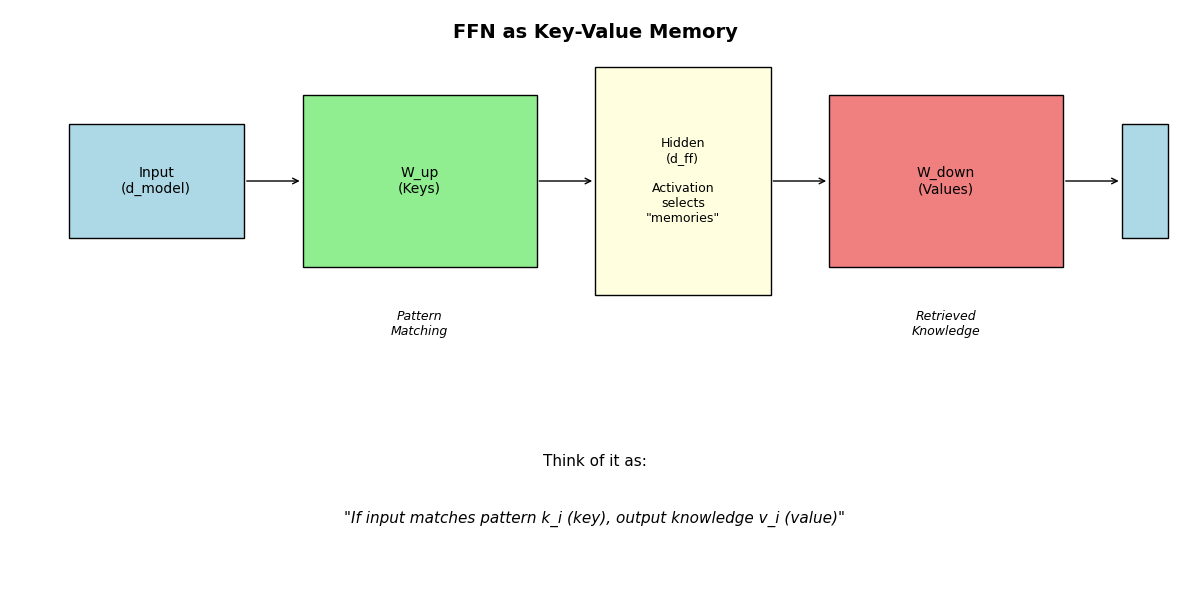

In [ ]:
# Visualize the "key-value memory" interpretation
fig, ax = plt.subplots(figsize=(12, 6))

ax.text(0.5, 0.95, 'FFN as Key-Value Memory', ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)

# Input
ax.add_patch(plt.Rectangle((0.05, 0.6), 0.15, 0.2, facecolor='lightblue', edgecolor='black'))
ax.text(0.125, 0.7, 'Input\n(d_model)', ha='center', va='center', fontsize=10)

# Arrow to W_up
ax.annotate('', xy=(0.25, 0.7), xytext=(0.2, 0.7),
            arrowprops=dict(arrowstyle='->', color='black'))

# W_up (Keys)
ax.add_patch(plt.Rectangle((0.25, 0.55), 0.2, 0.3, facecolor='lightgreen', edgecolor='black'))
ax.text(0.35, 0.7, 'W_up\n(Keys)', ha='center', va='center', fontsize=10)
ax.text(0.35, 0.45, 'Pattern\nMatching', ha='center', va='center', fontsize=9, style='italic')

# Arrow to hidden
ax.annotate('', xy=(0.5, 0.7), xytext=(0.45, 0.7),
            arrowprops=dict(arrowstyle='->', color='black'))

# Hidden (Activation)
ax.add_patch(plt.Rectangle((0.5, 0.5), 0.15, 0.4, facecolor='lightyellow', edgecolor='black'))
ax.text(0.575, 0.7, 'Hidden\n(d_ff)\n\nActivation\nselects\n"memories"', ha='center', va='center', fontsize=9)

# Arrow to W_down
ax.annotate('', xy=(0.7, 0.7), xytext=(0.65, 0.7),
            arrowprops=dict(arrowstyle='->', color='black'))

# W_down (Values)
ax.add_patch(plt.Rectangle((0.7, 0.55), 0.2, 0.3, facecolor='lightcoral', edgecolor='black'))
ax.text(0.8, 0.7, 'W_down\n(Values)', ha='center', va='center', fontsize=10)
ax.text(0.8, 0.45, 'Retrieved\nKnowledge', ha='center', va='center', fontsize=9, style='italic')

# Arrow to output
ax.annotate('', xy=(0.95, 0.7), xytext=(0.9, 0.7),
            arrowprops=dict(arrowstyle='->', color='black'))

# Output
ax.add_patch(plt.Rectangle((0.95, 0.6), 0.04, 0.2, facecolor='lightblue', edgecolor='black'))

# Bottom explanation
ax.text(0.5, 0.2, 'Think of it as:', ha='center', fontsize=11, transform=ax.transAxes)
ax.text(0.5, 0.1, '"If input matches pattern k_i (key), output knowledge v_i (value)"', 
        ha='center', fontsize=11, style='italic', transform=ax.transAxes)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: Benchmark Different FFNs

Compare speed and memory of Classic vs SwiGLU.

In [ ]:
# TODO: Time the forward pass of different FFN variants
# Which is fastest? Does it depend on d_model?

import time

def benchmark_ffn(ffn, x, num_iterations=100):
    # Warm up
    for _ in range(10):
        _ = ffn(x)
    
    # Time
    start = time.perf_counter()
    for _ in range(num_iterations):
        _ = ffn(x)
    elapsed = time.perf_counter() - start
    
    return elapsed * 1000  # Convert to ms

# Your benchmarking code here
# ...

### Exercise 2: ReGLU Implementation

Implement **ReGLU** (ReLU + GLU): $(xW_1) \odot \text{ReLU}(xW_2)$

In [ ]:
# TODO: Implement ReGLU

class ReGLU(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        # Your implementation here
        pass
    
    def forward(self, x):
        # Your implementation here
        pass

### Exercise 3: Activation Pattern Visualization

Visualize which hidden neurons activate for different inputs.

In [ ]:
# TODO: Create a small FFN and visualize the activation patterns
# in the hidden layer for different inputs

# Hint: Hook into the hidden layer to capture activations
# ...

---
## Summary

### What We Learned

1. **FFN Structure**: Expand → Activate → Compress (position-independent processing)

2. **Activation Evolution**: ReLU → GELU → SwiGLU (smoother, gated)

3. **Gated Linear Units**: Use one pathway to gate another - more expressive

4. **SwiGLU**: State-of-the-art, used in LLaMA/Mistral, 3 linear layers but reduced d_ff

5. **Knowledge Storage**: FFN layers seem to store factual knowledge as key-value pairs

### Key Formulas

```
Classic FFN:   FFN(x) = ReLU(xW₁ + b₁)W₂ + b₂
SwiGLU:        FFN(x) = (xW_up) ⊙ SiLU(xW_gate) → W_down
               where SiLU(x) = x × σ(x)
```

### Modern Recipe (LLaMA)

```
✅ SwiGLU activation
✅ No bias terms
✅ d_ff = 4 × d_model × (2/3), rounded to multiple of 256
✅ Combined with RMSNorm (pre-norm)
```

### Next Up: Complete Transformer Block

Now we have all the pieces! Let's put them together into a complete transformer block.